In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [3]:
df=pd.read_csv("university_admission.csv")

In [5]:
df.shape

(1000, 8)

In [6]:
df.columns
df


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
995,332,108,5,4.5,4.0,9.02,1,0.87
996,337,117,5,5.0,5.0,9.87,1,0.96
997,330,120,5,4.5,5.0,9.56,1,0.93
998,312,103,4,4.0,5.0,8.43,0,0.73


In [7]:
df.head()


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [9]:
df.describe



<bound method NDFrame.describe of      GRE_Score  TOEFL_Score  University_Rating  SOP  LOR  CGPA  Research  \
0          337          118                  4  4.5  4.5  9.65         1   
1          324          107                  4  4.0  4.5  8.87         1   
2          316          104                  3  3.0  3.5  8.00         1   
3          322          110                  3  3.5  2.5  8.67         1   
4          314          103                  2  2.0  3.0  8.21         0   
..         ...          ...                ...  ...  ...   ...       ...   
995        332          108                  5  4.5  4.0  9.02         1   
996        337          117                  5  5.0  5.0  9.87         1   
997        330          120                  5  4.5  5.0  9.56         1   
998        312          103                  4  4.0  5.0  8.43         0   
999        327          113                  4  4.5  4.5  9.04         0   

     Chance_of_Admission  
0                   0.92  

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GRE_Score            1000 non-null   int64  
 1   TOEFL_Score          1000 non-null   int64  
 2   University_Rating    1000 non-null   int64  
 3   SOP                  1000 non-null   float64
 4   LOR                  1000 non-null   float64
 5   CGPA                 1000 non-null   float64
 6   Research             1000 non-null   int64  
 7   Chance_of_Admission  1000 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 62.6 KB


In [11]:
df.isnull().sum()

GRE_Score              0
TOEFL_Score            0
University_Rating      0
SOP                    0
LOR                    0
CGPA                   0
Research               0
Chance_of_Admission    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(497)

In [14]:
df=df.drop(columns=["Chance_of_Admission"])

In [15]:
df

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
995,332,108,5,4.5,4.0,9.02,1
996,337,117,5,5.0,5.0,9.87,1
997,330,120,5,4.5,5.0,9.56,1
998,312,103,4,4.0,5.0,8.43,0


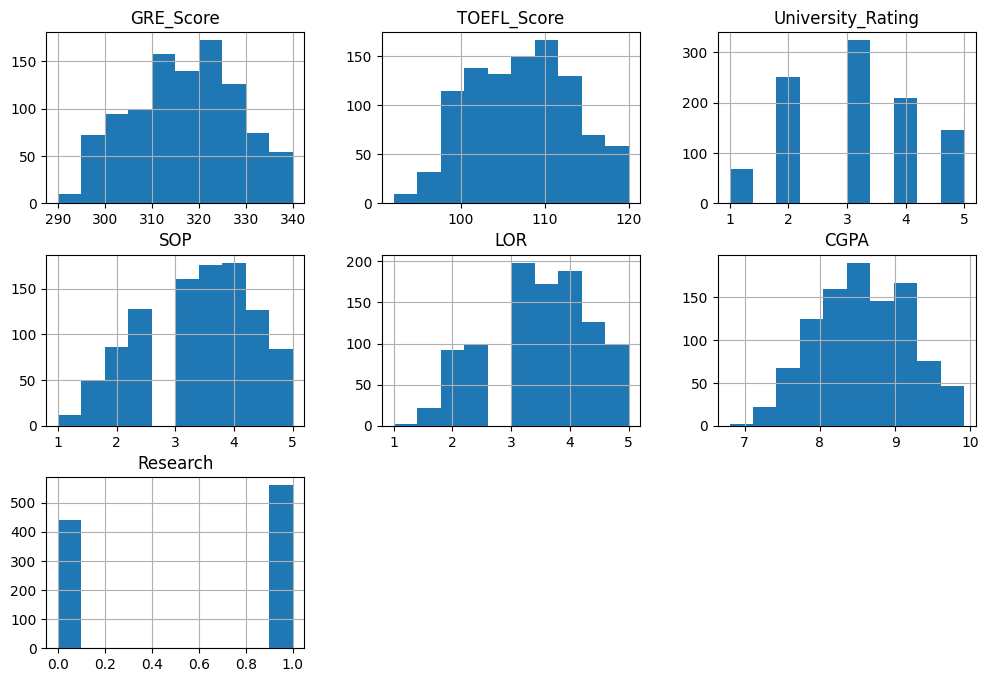

In [16]:
df.hist(figsize=(12,8))
plt.show()

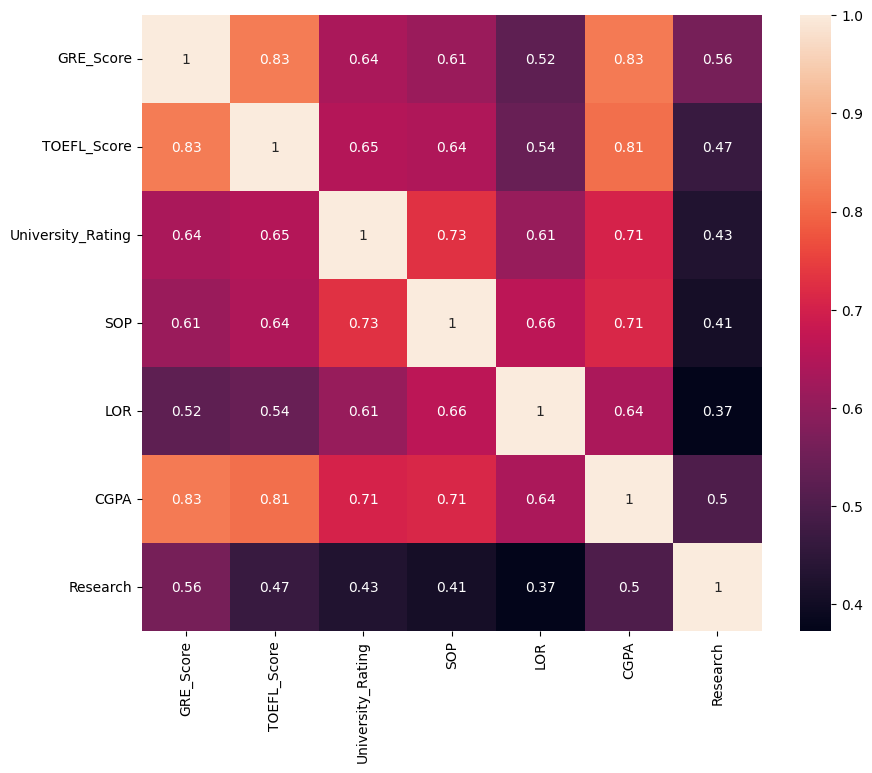

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [18]:
X=df

In [20]:
# Feature scaling  ---- bu yerda sonlarni urtacha darajaga keltiradi
scaler=StandardScaler()
X=scaler.fit_transform(df) 

In [21]:
# elbow method
wcss=[]
for k in range(1,11):
    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X)
    wcss.append(model.inertia_)
    

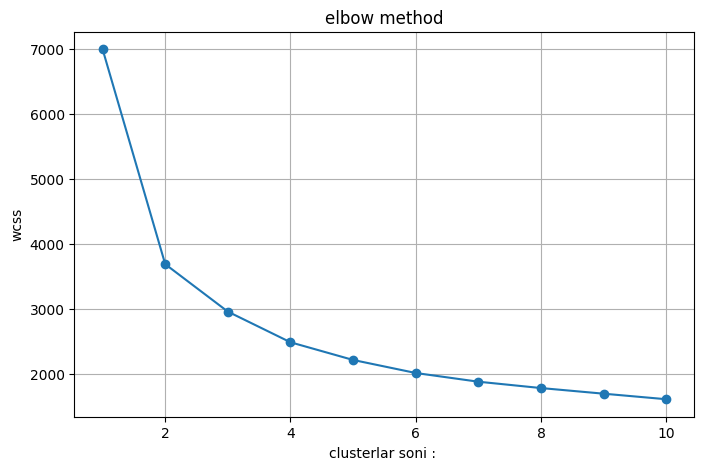

In [23]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("clusterlar soni : ")
plt.ylabel("wcss")
plt.title("elbow method")
plt.grid(True)
plt.show()


In [25]:
# model training
kmeans=KMeans(n_clusters=4, random_state=42, n_init=10)
clusters=kmeans.fit_predict(X)

In [29]:
df["Clusters"]=clusters

In [30]:
df

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,clusters,Clusters
0,337,118,4,4.5,4.5,9.65,1,1,1
1,324,107,4,4.0,4.5,8.87,1,1,1
2,316,104,3,3.0,3.5,8.00,1,3,3
3,322,110,3,3.5,2.5,8.67,1,3,3
4,314,103,2,2.0,3.0,8.21,0,0,0
...,...,...,...,...,...,...,...,...,...
995,332,108,5,4.5,4.0,9.02,1,1,1
996,337,117,5,5.0,5.0,9.87,1,1,1
997,330,120,5,4.5,5.0,9.56,1,1,1
998,312,103,4,4.0,5.0,8.43,0,2,2


In [31]:
df["Clusters"].value_counts()

Clusters
3    272
1    260
2    250
0    218
Name: count, dtype: int64

In [32]:
df.groupby("Clusters").mean(numeric_only=True)

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,clusters
Clusters,,,,,,,,
0,303.807339,100.385321,1.880734,2.174312,2.504587,7.863486,0.220183,0.0
1,329.423077,114.230769,4.446154,4.446154,4.373077,9.311923,0.923077,1.0
2,311.864000,105.480000,2.912000,3.336000,3.468000,8.431360,0.000000,2.0
3,318.477941,107.496324,3.014706,3.345588,3.433824,8.578162,1.000000,3.0


In [34]:
score=silhouette_score(X, clusters)
print(score)  #  biz klasterlar bir biridan qanchalik uzoqligini ulchash kerak 100 dan 80 uzoqlikda 27 yaqinlikda

0.27913710362381416


In [38]:
#cluster markazlari
centers=scaler.inverse_transform(kmeans.cluster_centers_)
centers=pd.DataFrame(centers,
                    columns=df.drop(columns="Clusters").columns)
centers           ##### qolibturadi

ValueError: Shape of passed values is (4, 7), indices imply (4, 8)